In [194]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import os
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler , OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [128]:
df=pd.read_csv("Data_Heart Problem_risk.csv")

In [129]:
df.head()

df.shape

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               3390 non-null   int64  
 1   age              3390 non-null   int64  
 2   education        3303 non-null   float64
 3   sex              3390 non-null   object 
 4   is_smoking       3390 non-null   object 
 5   cigsPerDay       3368 non-null   float64
 6   BPMeds           3346 non-null   float64
 7   prevalentStroke  3390 non-null   int64  
 8   prevalentHyp     3390 non-null   int64  
 9   diabetes         3390 non-null   int64  
 10  totChol          3352 non-null   float64
 11  sysBP            3390 non-null   float64
 12  diaBP            3390 non-null   float64
 13  BMI              3376 non-null   float64
 14  heartRate        3389 non-null   float64
 15  glucose          3086 non-null   float64
 16  TenYearCHD       3390 non-null   int64  
 17  predict_output

,id,age,education,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,predict_output
count,3390.000000,3390.000000,3303.000000,3368.000000,3346.000000,3390.000000,3390.000000,3390.000000,3352.000000,3390.00000,3390.000000,3376.000000,3389.000000,3086.000000,3390.000000,3390.000000
mean,1694.500000,49.542183,1.970936,9.069477,0.029886,0.006490,0.315339,0.025664,237.074284,132.60118,82.883038,25.794964,75.977279,82.086520,0.150737,0.125959
std,978.753033,8.592878,1.019081,11.879078,0.170299,0.080309,0.464719,0.158153,45.247430,22.29203,12.023581,4.115449,11.971868,24.244753,0.357846,0.331852
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.50000,48.000000,15.960000,45.000000,40.000000,0.000000,0.000000
25%,847.250000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.00000,74.500000,23.020000,68.000000,71.000000,0.000000,0.000000
50%,1694.500000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.50000,82.000000,25.380000,75.000000,78.000000,0.000000,0.000000
75%,2541.750000,56.000000,3.000000,20.000000,0.000000,0.000000,1.000000,0.000000,264.000000,144.00000,90.000000,28.040000,83.000000,87.000000,0.000000,0.000000
max,3389.000000,70.000000,4.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.00000,142.500000,56.800000,143.000000,394.000000,1.000000,1.000000


In [130]:
df.isnull().sum()
df.dropna(inplace=True)

In [131]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

['id', 'age', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'TenYearCHD', 'predict_output']


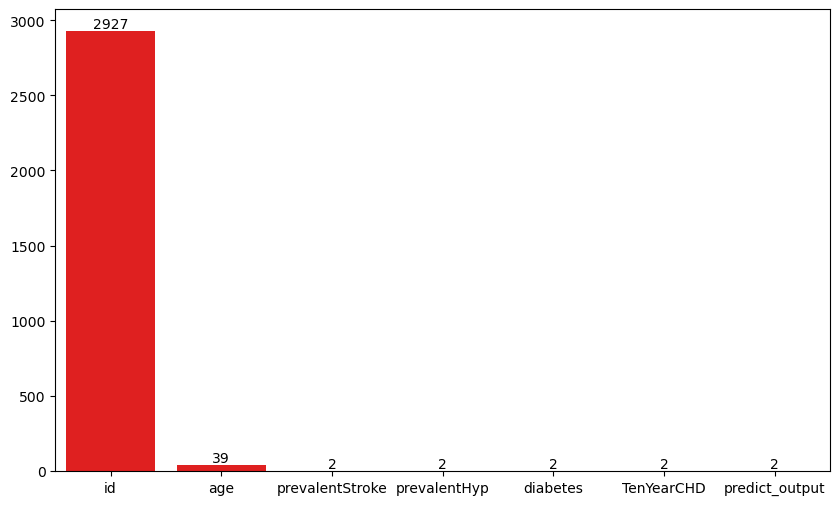

In [132]:
obj = df.dtypes == "int64"
obj_columns = list(obj[obj].index)
print(obj_columns)

unique_value=[]
for i in obj_columns:
    unique_value.append(df[i].unique().size)
unique_value

plt.figure(figsize=(10,6))
ax = sns.barplot(y=unique_value , x=obj_columns , color="red")
ax.bar_label(ax.containers[0])
plt.show()

<Axes: xlabel='is_smoking', ylabel='count'>

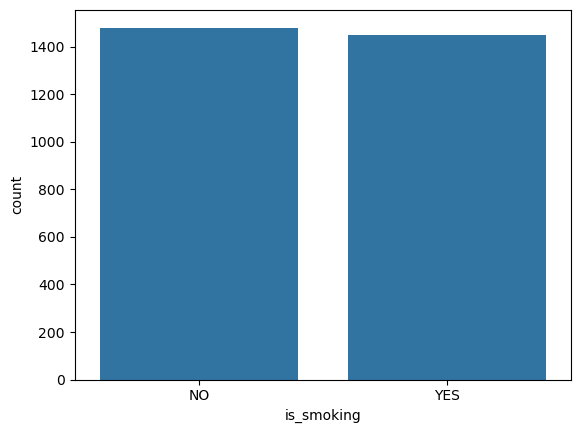

In [133]:
sns.countplot(x="is_smoking",data=df)

In [134]:
corr=df.select_dtypes(include='number').corr()

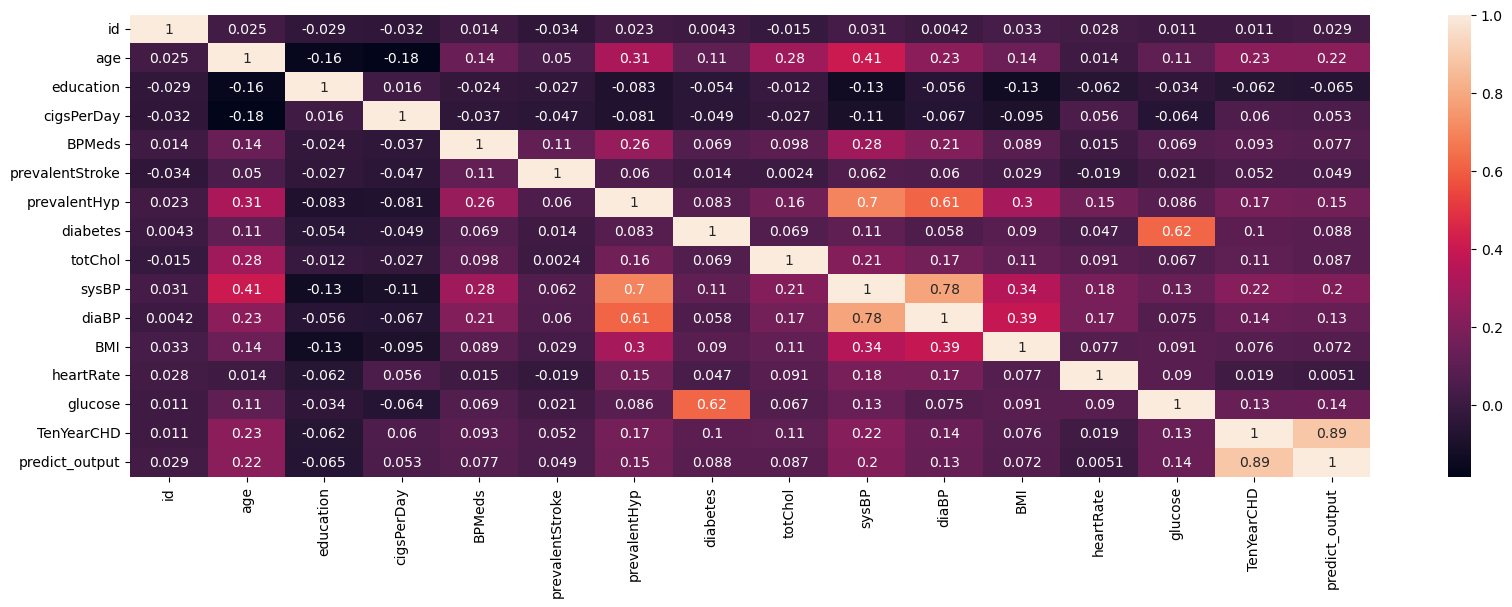

In [135]:
plt.figure(figsize=(20,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [136]:
df["Year"]=2025-df["age"]

In [137]:
import os
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler , OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier


In [138]:
x = df.drop(columns=["id", "TenYearCHD"])
y = df["TenYearCHD"]

In [139]:
cat_col = x.select_dtypes(include=object).columns
num_col=x.select_dtypes(exclude=object).columns

In [140]:
num_pipeline= Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

In [141]:
cat_pipeline= Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

In [142]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_col),
    ('cat', cat_pipeline, cat_col)
])

In [143]:
model =Pipeline(steps=[
                 ('preprocessor', preprocessor),
                 ('classfication', RandomForestClassifier(n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42))
])

In [144]:
x_train , x_test , y_train , y_test = train_test_split(x,y, test_size=.20 , random_state=42)

In [145]:
model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  Index(['age', 'education', 'cigsPerDay', 'BPMeds', 'prevalentStroke',
       'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI',
       'heartRate', 'glucose', 'predict_output', 'Year'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  Index(['sex', 'is_smoking'], dtype='object'))])),
                ('classfication',
                 RandomForestClassifier(max_depth=10, min_samples_leaf=2,
                                        min_samples_split=5, n_estimators=300,
                                        random_state=42))])

In [146]:
y_pred = model.predict(x_test)

In [147]:
y_train_score = model.score(x_train,y_train)
y_test_score = model.score(x_test,y_test)

print(y_test_score,"test")
print(y_train_score,"train")

0.9675767918088737 test
0.9747970952584366 train


In [148]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9675767918088737
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       496
           1       0.97      0.81      0.88        90

    accuracy                           0.97       586
   macro avg       0.97      0.90      0.93       586
weighted avg       0.97      0.97      0.97       586

[[494   2]
 [ 17  73]]


In [149]:
predict=model.predict(x)

In [150]:
df['predict_output'] = predict

In [151]:
df['predict_output'].value_counts()

predict_output
0    2551
1     376
Name: count, dtype: int64

In [192]:
df.head()

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,predict_output,Year
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0,0,1989
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0,0,1979
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1,1,1975
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0,0,1961
5,5,61,3.0,F,NO,0.0,0.0,0,1,0,272.0,182.0,121.0,32.80,85.0,65.0,1,1,1964


In [202]:
df.to_csv("heart_clen_data.csv", index=False)

In [204]:
import os
print(os.getcwd())

C:\Users\Ganesh\Class Practice


In [206]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\Ganesh\Class Practice
['.ipynb_checkpoints', 'class2.ipynb', 'clean_copun_data.csv', 'clean_data.csv', 'Coffe_sales.csv', 'comprehensive_mutual_funds_data.csv', 'coupon pipline.ipynb', 'CouponAccept.csv', 'CouponAccept.ipynb', 'coupon_data.csv', 'cuppon2.ipynb', 'data.csv', 'data.xls.xlsx', 'datacsv.ipynb', 'dataset 2.csv', 'Data_Heart Problem_risk.csv', 'development .ipynb', 'function.ipynb', 'heart file.ipynb', 'HeartData.ipynb', 'heart_clen_data.csv', 'heart_model.pkl', 'Heart_Risk_Analysis_Report.pptx', 'High_Risk_People.csv', 'home work 3cupan accept.ipynb', 'HOME WORK taitenic.ipynb', 'homework1.ipynb', 'Low_Risk_People.csv', 'machine learning code.ipynb', 'MACHINE LEARNING.ipynb', 'Medium_Risk_People.csv', 'mental_health_survey_dataset.ipynb', 'mental_health_survey_dataset_300k.csv', 'ml code revision.ipynb', 'ml program.ipynb', 'ml sort summry.ipynb', 'Mobile Sales Data.xlsx', 'Moderate_Risk_People.csv', 'modified_titanic.csv', 'MONGODB.ipynb', 'myntra.ipynb', 'MYSQL.i

In [208]:
import os

print(os.getcwd())

df.to_csv(r"C:\Users\Ganesh\Downloads\heart_clen_data.csv", index=False)

print(os.path.exists(r"C:\Users\Ganesh\Downloads\heart_clen_data.csv"))

C:\Users\Ganesh\Class Practice
True


In [210]:
import mysql.connector

conn=mysql.connector.connect(
host="localhost",
user="root",
password="root",
database="heart_db"
)